# CS476: Natural Language Processing
## Course Project — Arabic Legal Document Classification
### Tasks: A (Verdict Prediction) + B (Legal Topic Classification)
**Dataset:** ALARB — Arabic Legal Argument Reasoning Benchmark  

**Instructor:** Dr. Fatima AlShannaq

**Team Members:**

- Layal Alsultan 221410010

- Areen Al Ruwaitea 222410547

- Nouf Alsalman 222410203

---

> **AI Disclosure:** Some parts of this notebook were assisted by AI tools.  
> **Prompts used:**  
> 1. *"What are the best Arabic NLP preprocessing techniques for legal text?"*  
> 2. *"How to build a simple BiLSTM text classifier in Keras for Arabic text?"*  
> AI-generated content does not exceed 30% of total work.

## Section 0 — Install Dependencies

In [ ]:
!pip install numpy==1.26.4 -q
!pip install datasets arabert pyarabic gensim -q
!pip install scikit-learn matplotlib seaborn pandas -q
!pip install arabic-reshaper python-bidi -q

import nltk
nltk.download('stopwords', quiet=True)

True

## Section 1 — Imports

In [ ]:
import re
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import seaborn as sns
from collections import Counter #, #defaultdict

# Dataset
from datasets import load_dataset

# Arabic NLP
import pyarabic.araby as araby
from nltk.stem.isri import ISRIStemmer

# Feature extraction
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# ML models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

# Neural network
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout #, Embedding, GlobalAveragePooling1D
# from tensorflow.keras.preprocessing.text import Tokenizer
#from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

# Arabic Reshaper
import arabic_reshaper
from bidi.algorithm import get_display

def fix_arabic(text):
    return get_display(arabic_reshaper.reshape(text))

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print('All imports successful.')
print(f'TensorFlow version: {tf.__version__}')

All imports successful.
TensorFlow version: 2.20.0


## Section 2 — Load Dataset

In [ ]:
# Load ALARB dataset from HuggingFace
df = load_dataset('THIQAH-RD/ALARB', split='train').to_pandas()

print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(2)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/19.1M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/2.15M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/12012 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1329 [00:00<?, ? examples/s]

Dataset shape: (12012, 4)
Columns: ['case_facts', 'court_reasoning', 'applicable_laws', 'verdict']


,case_facts,court_reasoning,applicable_laws,verdict
0,[1- بتاريخ 1443/09/06 اتفق أطراف الدعوى على أن...,[1- بناءً على الدعوى والإجابة، طلب وكيل المدعي...,[نظام المحاكم التجارية:22: ١.تحيل الإدارة المخ...,إثبات الصلح بين الطرفين وإلزام المدعى عليها بس...
1,[1. سبق أن تم رفع دعوى من مصنع تكنولوجيا الحدي...,[1. اعتبرت الدائرة أن اختصاص النظر في النزاع ي...,[نظام المحاكم التجارية:16: تختص المحكمة بالنظر...,"إلزام المدعى عليها بدفع مبلغ 72,000 ريال للمدع..."


## Section 3 — Exploratory Data Analysis

In [ ]:
# Check what verdict values look like
df['verdict'].value_counts().head(20).to_frame('count')

,count
verdict,
حكمت المحكمة بعدم قبول الدعوى لرفعها على غير ذي صفة.,30
حكمت المحكمة بعدم قبول الدعوى لرفعها من غير ذي صفة.,24
قررت المحكمة عدم قبول الدعوى لرفعها على غير ذي صفة.,12
حكمت المحكمة بعدم قبول الدعوى لإقامتها على غير ذي صفة.,12
حكمت الدائرة بعدم قبول الدعوى لرفعها من غير ذي صفة.,11
حكمت الدائرة بعدم قبول الدعوى لرفعها على غير ذي صفة.,10
حكمت الدائرة بعدم قبول الدعوى لإقامتها على غير ذي صفة.,9
حكمت الدائرة بعدم اختصاص المحكمة التجارية نوعياً بنظر الدعوى وإحالتها للمحكمة العامة.,7
حكمت المحكمة بعدم اختصاصها نوعياً بنظر الدعوى وأحالتها للمحكمة العامة.,5


Document Length Statistics (case_facts)
count    12012.000000
mean       181.247752
std         48.972762
min         36.000000
25%        146.000000
50%        177.000000
75%        213.000000
max        398.000000
Name: doc_length, dtype: float64


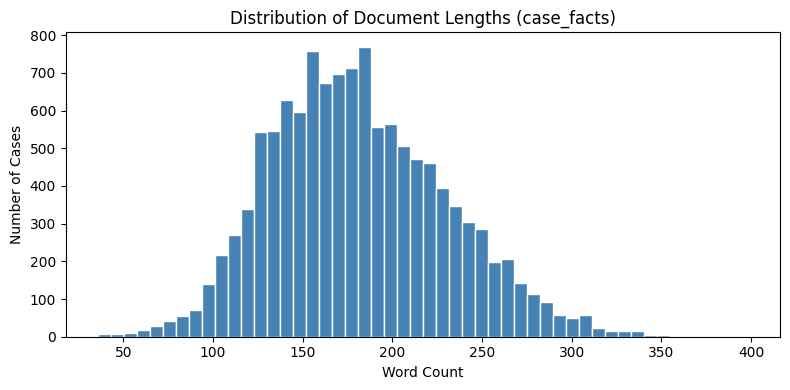

In [ ]:
# Document length analysis for case_facts
def get_text(val):
    if isinstance(val, list):
        return ' '.join([str(v) for v in val])
    return str(val)

df['case_facts_text'] = df['case_facts'].apply(get_text)
df['doc_length'] = df['case_facts_text'].apply(lambda x: len(x.split()))

print('Document Length Statistics (case_facts)')
print(df['doc_length'].describe())

plt.figure(figsize=(8, 4))
plt.hist(df['doc_length'], bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Word Count')
plt.ylabel('Number of Cases')
plt.title('Distribution of Document Lengths (case_facts)')
plt.tight_layout()
plt.show()

## Section 4 — Label Engineering

### 4A — Task A: Verdict Labels
Map raw Arabic verdict text into 5 classes:
- **مقبولة كلياً** → Fully Accepted  
- **مقبولة جزئياً** → Partially Accepted  
- **مرفوضة** → Rejected  
- **صلح** → Settlement  
- **عدم اختصاص** → Dismissed

In [ ]:
def map_verdict(text):

    t = str(text).strip()

    # Dismissed / no jurisdiction
    if any(kw in t for kw in ['عدم الاختصاص', 'عدم اختصاص', 'إحالة', 'احالة']):
        return 'عدم اختصاص'

    # Settlement
    if any(kw in t for kw in ['صلح', 'تسوية', 'الصلح']):
        return 'صلح'

    # Partial acceptance
    if any(kw in t for kw in ['جزئ', 'جزئياً', 'جزئيا', 'بعض']):
        return 'مقبولة جزئياً'

    # Rejection
    if any(kw in t for kw in ['مرفوض', 'رفض', 'الرفض']):
        return 'مرفوضة'

    # Full acceptance
    if any(kw in t for kw in ['مقبول', 'قبول', 'إلزام', 'الزام', 'يلزم']):
        return 'مقبولة كلياً'

    return 'أخرى'


df['verdict_label'] = df['verdict'].apply(map_verdict)

# Drop 'أخرى' since it's ambiguous
df_a = df[df['verdict_label'] != 'أخرى'].copy()


print(f'Records after removing ambiguous: {len(df_a)} / {len(df)}')
df['verdict_label'].value_counts().to_frame('count')

Records after removing ambiguous: 9374 / 12012


,count
verdict_label,
مقبولة كلياً,5424
أخرى,2638
مرفوضة,2087
صلح,1069
عدم اختصاص,764
مقبولة جزئياً,30


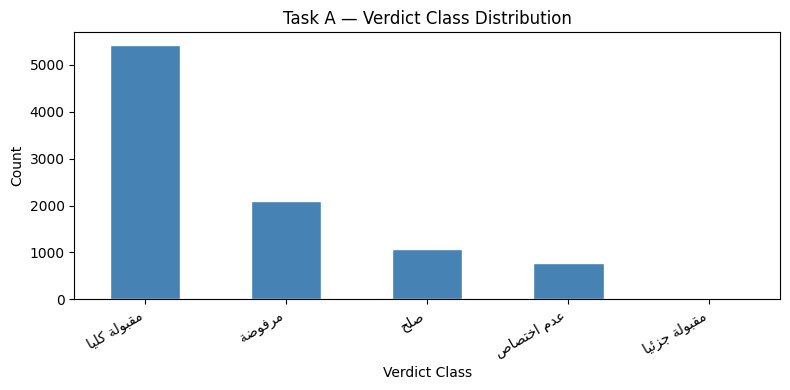

In [ ]:
# Plot Task A label distribution
counts_a = df_a['verdict_label'].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
counts_a.plot(kind='bar', color='steelblue', edgecolor='white', ax=ax)
ax.set_title('Task A — Verdict Class Distribution')
ax.set_xlabel('Verdict Class')
ax.set_ylabel('Count')
ax.set_xticklabels([fix_arabic(label.get_text()) for label in ax.get_xticklabels()], rotation=30, ha='right')
plt.tight_layout()
plt.show()


### 4B — Task B: Legal Topic Labels

Labels are derived by parsing the `applicable_laws` column and mapping dominant cited law names to topic categories.  
This is a **rule-based label derivation**

In [ ]:
def parse_applicable_laws(laws_field):
    """
    Parse the applicable_laws field and return a list of
    (law_name, article_no) tuples.
    Each entry format: LawName:ArticleNo:FullText
    """
    results = []
    try:
        if not laws_field:
          return results
    except ValueError:
        pass

    # Handle list or string
    if isinstance(laws_field, list):
        entries = laws_field
    else:
        entries = [str(laws_field)]

    for entry in entries:
        entry = str(entry).strip()
        parts = entry.split(':')
        if len(parts) >= 2:
            law_name = parts[0].strip()
            article_no = parts[1].strip()
            results.append((law_name, article_no))
    return results


def map_topic(laws_field):
    """
    Derive a legal topic label from cited laws.
    Priority is given to the most domain-specific law cited.
    """
    parsed = parse_applicable_laws(laws_field)
    if not parsed:
        return None  # Will drop these rows

    # Collect all law names for this case
    law_names = [p[0] for p in parsed]
    combined = ' '.join(law_names)

    # Rule-based mapping — order from most specific to most general
    if any(kw in combined for kw in ['العمل', 'العمالة', 'العمال', 'الموارد البشرية']):
        return 'نزاعات عمالية'  # Labor disputes

    if any(kw in combined for kw in ['المقاولات', 'المقاول', 'الإنشاء', 'التشييد']):
        return 'عقود مقاولات'  # Construction contracts

    if any(kw in combined for kw in ['الملكية الفكرية', 'العلامة التجارية', 'براءة', 'حقوق']):
        return 'ملكية فكرية'  # Intellectual property

    if any(kw in combined for kw in ['الشركات', 'شركة', 'شراكة', 'المضاربة', 'العنان']):
        return 'شراكات تجارية'  # Commercial partnerships

    if any(kw in combined for kw in ['التوريد', 'البيع', 'الشراء', 'المبيع', 'التجارية']):
        return 'عقود بيع وتوريد'  # Sales & supply

    if any(kw in combined for kw in ['التعويض', 'الضرر', 'الأضرار', 'المسؤولية']):
        return 'تعويضات وأضرار'  # Damages & compensation

    if any(kw in combined for kw in ['التمويل', 'الدين', 'القرض', 'الديون', 'الاستثمار']):
        return 'تمويل وديون'  # Finance & debt

    # Default: generic commercial dispute
    return 'نزاعات تجارية عامة'


df['topic_label'] = df['applicable_laws'].apply(map_topic)

# Drop rows with no applicable_laws (cannot derive label)
df_b = df[df['topic_label'].notna()].copy()

print(f'Records with topic labels: {len(df_b)} / {len(df)}')
print(f'Records dropped (empty applicable_laws): {len(df) - len(df_b)}')
df_b['topic_label'].value_counts().to_frame('count')

Records with topic labels: 11126 / 12012
Records dropped (empty applicable_laws): 886


,count
topic_label,
عقود بيع وتوريد,7222
نزاعات تجارية عامة,3511
شراكات تجارية,393


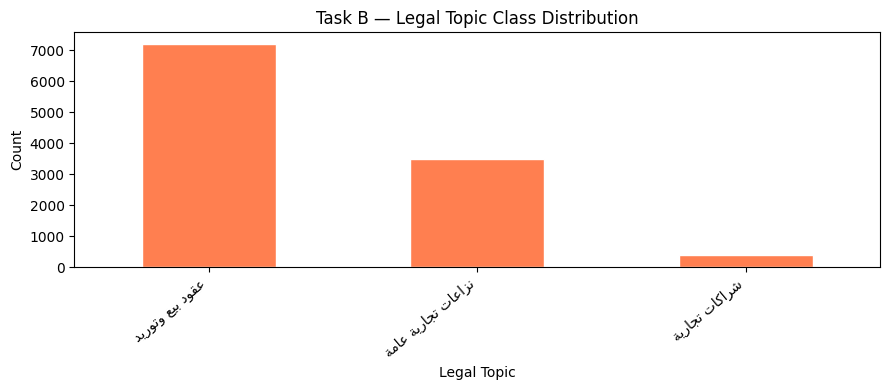

In [ ]:
# Plot Task B label distribution
counts_b = df_b['topic_label'].value_counts()

fig, ax = plt.subplots(figsize=(9, 4))
counts_b.plot(kind='bar', color='coral', edgecolor='white', ax=ax)
ax.set_title('Task B — Legal Topic Class Distribution')
ax.set_xlabel('Legal Topic')
ax.set_ylabel('Count')
ax.set_xticklabels([fix_arabic(label.get_text()) for label in ax.get_xticklabels()], rotation=40, ha='right')
plt.tight_layout()
plt.show()

## Section 5 — Arabic Text Preprocessing

We implement **6 Arabic-specific cleaning techniques**:
1. Normalize Alef variants (أ، إ، آ → ا) and Taa Marbuta (ة → ه)
2. Remove diacritics (tashkeel) and tatweel (ـ)
3. Remove punctuation and non-Arabic characters
4. Handle legal-specific tokens (case numbers, dates, monetary amounts)
5. Arabic stopword removal (legal-domain curated list)
6. Arabic stemming using ISRIStemmer

In [ ]:
# Technique 1: Character normalization
def normalize_arabic(text):
    text = re.sub('[إأآا]', 'ا', text)
    text = re.sub('ة', 'ه', text)
    text = re.sub('[يى]', 'ي', text)
    text = re.sub('ؤ', 'و', text)
    text = re.sub('ئ', 'ي', text)
    return text


# Technique 2: Remove tashkeel and tatweel
def remove_diacritics_tatweel(text):
    text = araby.strip_tashkeel(text)
    text = araby.strip_tatweel(text)
    return text


# Technique 3: Remove non-Arabic characters and keep whitespace
def remove_non_arabic(text):
    text = re.sub(r'[^\u0600-\u06FF\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


# Technique 4: Handle legal-specific tokens
def handle_legal_tokens(text):
    # Monetary amounts
    text = re.sub(r'\d[\d,\.]*\s*(ريال|ر\.س)', 'مبلغ', text)
    # Hijri dates (format: 1440/05/10 or 1440-05-10)
    text = re.sub(r'1[34]\d{2}[/\-]\d{1,2}[/\-]\d{1,2}', 'تاريخهجري', text)
    # Gregorian dates
    text = re.sub(r'20\d{2}[/\-]\d{1,2}[/\-]\d{1,2}', 'تاريخميلادي', text)
    # Case numbers (usually long digit strings)
    text = re.sub(r'\b\d{6,}\b', 'قضية', text)
    # Remaining numbers
    text = re.sub(r'\b\d+\b', '', text)
    return text



# Technique 5: Arabic stopword removal
# Generic Arabic stopwords + legal-domain specific ones
ARABIC_STOPWORDS = set([
    'في', 'من', 'إلى', 'على', 'عن', 'مع', 'هذا', 'هذه', 'ذلك', 'تلك',
    'التي', 'الذي', 'الذين', 'اللتي', 'اللذين', 'كما', 'كان', 'كانت',
    'لم', 'لا', 'ما', 'ان', 'أن', 'إن', 'و', 'أو', 'ثم', 'حيث',
    'قد', 'قدم', 'بعد', 'قبل', 'حتى', 'لقد', 'لكن', 'أما', 'إذ',
    'وقد', 'وكان', 'وان', 'وأن', 'كذلك', 'أيضا', 'غير', 'بل',
    # Legal-domain specific stopwords
    'الدعوى', 'الدائره', 'الدائرة', 'المحكمه', 'المحكمة', 'القضية',
    'الطلب', 'الحكم', 'القرار', 'المدعي', 'المدعى', 'المدعيه',
    'المدعية', 'عليه', 'عليها', 'وكيل', 'ممثل', 'جلسه', 'جلسة'
])

def remove_stopwords(text):
    tokens = text.split()
    tokens = [t for t in tokens if t not in ARABIC_STOPWORDS and len(t) > 2]
    return ' '.join(tokens)


# Technique 6: Arabic stemming
stemmer = ISRIStemmer()

def stem_arabic(text):
    # Apply ISRI stemmer to each token
    tokens = text.split()
    tokens = [stemmer.stem(t) for t in tokens]
    return ' '.join(tokens)


# Full pipeline
def preprocess(text, use_stemming=True):
    text = str(text)
    text = handle_legal_tokens(text)       # Technique 4
    text = remove_diacritics_tatweel(text) # Technique 2
    text = normalize_arabic(text)          # Technique 1
    text = remove_non_arabic(text)         # Technique 3
    text = remove_stopwords(text)          # Technique 5
    if use_stemming:
        text = stem_arabic(text)           # Technique 6
    return text


print('Preprocessing functions defined.')


sample = df['case_facts_text'].iloc[0]
pd.DataFrame({
    'Version': ['Original', 'Cleaned'],
    'Text': [sample[:200], preprocess(sample)[:200]]
})

Preprocessing functions defined.


,Version,Text
0,Original,['1- بتاريخ 1443/09/06 اتفق أطراف الدعوى على أ...
1,Cleaned,ارخ تاريخهجري تفق طرف دعي علي ورد دعي عمل بثم ...


In [ ]:
# Apply preprocessing to both task dataframes
print('Preprocessing Task A texts')
df_a['clean_text'] = df_a['case_facts_text'].apply(preprocess)
df_a['clean_text_nostem'] = df_a['case_facts_text'].apply(lambda x: preprocess(x, use_stemming=False))

print('Preprocessing Task B texts')
df_b['clean_text'] = df_b['case_facts_text'].apply(preprocess)
df_b['clean_text_nostem'] = df_b['case_facts_text'].apply(lambda x: preprocess(x, use_stemming=False))

print('Done.')
print(f'Task A samples: {len(df_a)}')
print(f'Task B samples: {len(df_b)}')

Preprocessing Task A texts
Preprocessing Task B texts
Done.
Task A samples: 9374
Task B samples: 11126


In [ ]:
# Compare stemmed vs non-stemmed vocabulary size
all_tokens_stem = ' '.join(df_a['clean_text']).split()
all_tokens_nostem = ' '.join(df_a['clean_text_nostem']).split()

vocab_stem = len(set(all_tokens_stem))
vocab_nostem = len(set(all_tokens_nostem))

print('Stemming Impact on Vocabulary')
print(f'Vocabulary size WITHOUT stemming: {vocab_nostem:,}')
print(f'Vocabulary size WITH stemming:    {vocab_stem:,}')
print(f'Reduction: {((vocab_nostem - vocab_stem) / vocab_nostem * 100):.1f}%')


Stemming Impact on Vocabulary
Vocabulary size WITHOUT stemming: 37,952
Vocabulary size WITH stemming:    9,698
Reduction: 74.4%


## Section 6 — Train/Test Split

In [ ]:
# Task A split
le_a = LabelEncoder()
y_a = le_a.fit_transform(df_a['verdict_label'])
X_a = df_a['clean_text'].values
X_a_nostem = df_a['clean_text_nostem'].values

X_a_train, X_a_test, y_a_train, y_a_test = train_test_split(
    X_a, y_a, test_size=0.2, random_state=42, stratify=y_a
)

# Task B split
le_b = LabelEncoder()
y_b = le_b.fit_transform(df_b['topic_label'])
X_b = df_b['clean_text'].values

X_b_train, X_b_test, y_b_train, y_b_test = train_test_split(
    X_b, y_b, test_size=0.2, random_state=42, stratify=y_b
)

print('Task A Split')
print(f'Train: {len(X_a_train)}  |  Test: {len(X_a_test)}')
print('Classes:', list(le_a.classes_))

print('\nTask B Split')
print(f'Train: {len(X_b_train)}  |  Test: {len(X_b_test)}')
print('Classes:', list(le_b.classes_))

Task A Split
Train: 7499  |  Test: 1875
Classes: ['صلح', 'عدم اختصاص', 'مرفوضة', 'مقبولة جزئياً', 'مقبولة كلياً']

Task B Split
Train: 8900  |  Test: 2226
Classes: ['شراكات تجارية', 'عقود بيع وتوريد', 'نزاعات تجارية عامة']


## Section 7 — Feature Extraction

### 7.1 Bag of Words (BoW)

In [ ]:
# Task A
bow_vec_a = CountVectorizer(max_features=10000)
X_a_bow_train = bow_vec_a.fit_transform(X_a_train)
X_a_bow_test  = bow_vec_a.transform(X_a_test)

# Task B
bow_vec_b = CountVectorizer(max_features=10000)
X_b_bow_train = bow_vec_b.fit_transform(X_b_train)
X_b_bow_test  = bow_vec_b.transform(X_b_test)

print('BoW feature matrix shapes:')
print(f'  Task A train: {X_a_bow_train.shape}')
print(f'  Task B train: {X_b_bow_train.shape}')
print(f'\nVocabulary size (Task A BoW): {len(bow_vec_a.vocabulary_):,}')
print(f'Vocabulary size (Task B BoW): {len(bow_vec_b.vocabulary_):,}')

BoW feature matrix shapes:
  Task A train: (7499, 8208)
  Task B train: (8900, 8679)

Vocabulary size (Task A BoW): 8,208
Vocabulary size (Task B BoW): 8,679


### 7.2 TF-IDF (Unigrams and Bigrams)

In [ ]:
# Unigram TF-IDF
tfidf_uni_a = TfidfVectorizer(max_features=10000, ngram_range=(1,1))
X_a_tfidf_train = tfidf_uni_a.fit_transform(X_a_train)
X_a_tfidf_test  = tfidf_uni_a.transform(X_a_test)

tfidf_uni_b = TfidfVectorizer(max_features=10000, ngram_range=(1,1))
X_b_tfidf_train = tfidf_uni_b.fit_transform(X_b_train)
X_b_tfidf_test  = tfidf_uni_b.transform(X_b_test)

# Bigram TF-IDF
tfidf_bi_a = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_a_tfidf_bi_train = tfidf_bi_a.fit_transform(X_a_train)
X_a_tfidf_bi_test  = tfidf_bi_a.transform(X_a_test)

tfidf_bi_b = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_b_tfidf_bi_train = tfidf_bi_b.fit_transform(X_b_train)
X_b_tfidf_bi_test  = tfidf_bi_b.transform(X_b_test)

print('TF-IDF feature matrix shapes:')
print(f'  Task A unigram: {X_a_tfidf_train.shape}')
print(f'  Task A bigram:  {X_a_tfidf_bi_train.shape}')
print(f'  Task B unigram: {X_b_tfidf_train.shape}')
print(f'  Task B bigram:  {X_b_tfidf_bi_train.shape}')

# Show top TF-IDF terms for Task A
feature_names = tfidf_uni_a.get_feature_names_out()
print(f'\nSample TF-IDF features (Task A):', list(feature_names[:10]))

TF-IDF feature matrix shapes:
  Task A unigram: (7499, 8208)
  Task A bigram:  (7499, 10000)
  Task B unigram: (8900, 8679)
  Task B bigram:  (8900, 10000)

Sample TF-IDF features (Task A): ['اء', 'اب', 'ابء', 'ابا', 'ابب', 'ابت', 'ابتدايي', 'ابتداييه', 'ابث', 'ابد']


### 7.3 N-grams: Word-level and Character-level

In [ ]:
# Word-level trigrams (Task A)
tfidf_word_tri_a = TfidfVectorizer(max_features=8000, ngram_range=(2,3), analyzer='word')
X_a_word_tri_train = tfidf_word_tri_a.fit_transform(X_a_train)
X_a_word_tri_test  = tfidf_word_tri_a.transform(X_a_test)

# Character-level trigrams (Task A)
tfidf_char_tri_a = TfidfVectorizer(max_features=8000, ngram_range=(3,4), analyzer='char_wb')
X_a_char_tri_train = tfidf_char_tri_a.fit_transform(X_a_train)
X_a_char_tri_test  = tfidf_char_tri_a.transform(X_a_test)

# Word-level trigrams (Task B)
tfidf_word_tri_b = TfidfVectorizer(max_features=8000, ngram_range=(2,3), analyzer='word')
X_b_word_tri_train = tfidf_word_tri_b.fit_transform(X_b_train)
X_b_word_tri_test  = tfidf_word_tri_b.transform(X_b_test)

# Character-level trigrams (Task B)
tfidf_char_tri_b = TfidfVectorizer(max_features=8000, ngram_range=(3,4), analyzer='char_wb')
X_b_char_tri_train = tfidf_char_tri_b.fit_transform(X_b_train)
X_b_char_tri_test  = tfidf_char_tri_b.transform(X_b_test)

print('N-gram feature shapes (Task A):')
print(f'  Word trigrams:  {X_a_word_tri_train.shape}')
print(f'  Char trigrams:  {X_a_char_tri_train.shape}')
print('\nN-gram feature shapes (Task B):')
print(f'  Word trigrams:  {X_b_word_tri_train.shape}')
print(f'  Char trigrams:  {X_b_char_tri_train.shape}')

N-gram feature shapes (Task A):
  Word trigrams:  (7499, 8000)
  Char trigrams:  (7499, 8000)

N-gram feature shapes (Task B):
  Word trigrams:  (8900, 8000)
  Char trigrams:  (8900, 8000)


### 7.4 Word Embeddings (AraVec — averaged Word2Vec)

We download the AraVec pretrained Word2Vec model for Arabic and represent each document as the **average of its word vectors**.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

for root, dirs, files in os.walk('/content/drive/.shortcut-targets-by-id'):
    for file in files:
        if 'cbow' in file.lower() or 'aravec' in file.lower():
            print(os.path.join(root, file))

In [ ]:
from gensim.models import Word2Vec

ARAVEC_PATH = '/content/drive/.shortcut-targets-by-id/18RgOrS9sCljlqkA_bEkETHYxvJXd37wf/aravec_model/full_uni_cbow_300_twitter.mdl'

print('Loading AraVec model...')
try:
    aravec_model = Word2Vec.load(ARAVEC_PATH).wv
    EMBED_DIM = aravec_model.vector_size
    print(f'AraVec loaded successfully!')
    print(f'Embedding dimension: {EMBED_DIM}')
    print(f'Vocabulary size: {len(aravec_model.key_to_index):,}')
except Exception as e:
    print(f'Failed to load: {e}')
    aravec_model = None
    EMBED_DIM = 300

Loading AraVec model...
AraVec loaded successfully!
Embedding dimension: 300
Vocabulary size: 1,259,756


In [ ]:
def text_to_avg_vector(text, model, dim):

    tokens = text.split()
    vectors = []
    oov = 0
    for token in tokens:
        if model is not None and token in model:
            vectors.append(model[token])
        else:
            oov += 1
    if vectors:
        return np.mean(vectors, axis=0), oov, len(tokens)
    return np.zeros(dim), oov, len(tokens)


def compute_embeddings(texts, model, dim):
    vecs = []
    total_oov = 0
    total_tokens = 0
    for text in texts:
        v, oov, n = text_to_avg_vector(text, model, dim)
        vecs.append(v)
        total_oov += oov
        total_tokens += n
    oov_rate = total_oov / total_tokens if total_tokens > 0 else 0
    return np.array(vecs), oov_rate


print('Computing embedding features')

# Task A
X_a_emb_train, oov_a_train = compute_embeddings(X_a_train, aravec_model, EMBED_DIM)
X_a_emb_test,  oov_a_test  = compute_embeddings(X_a_test,  aravec_model, EMBED_DIM)

# Task B
X_b_emb_train, oov_b_train = compute_embeddings(X_b_train, aravec_model, EMBED_DIM)
X_b_emb_test,  oov_b_test  = compute_embeddings(X_b_test,  aravec_model, EMBED_DIM)

print(f'\nEmbedding dimension: {EMBED_DIM}')
print(f'Task A embedding shape: {X_a_emb_train.shape}')
print(f'Task A OOV rate (train): {oov_a_train:.2%}')
print(f'Task B OOV rate (train): {oov_b_train:.2%}')

Computing embedding features

Embedding dimension: 300
Task A embedding shape: (7499, 300)
Task A OOV rate (train): 5.19%
Task B OOV rate (train): 5.20%


## Section 8 — Helper: Evaluation Function

In [ ]:
def evaluate_model(y_true, y_pred, label_encoder, task_name='', model_name=''):

    classes = label_encoder.classes_

    acc        = accuracy_score(y_true, y_pred)
    p_macro    = precision_score(y_true, y_pred, average='macro', zero_division=0)
    r_macro    = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_macro   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    summary = pd.DataFrame({
        'Metric': ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 (macro)', 'F1 (weighted)'],
        'Score':  [acc, p_macro, r_macro, f1_macro, f1_weighted]
    })
    summary['Score'] = summary['Score'].round(4)

    print(f'\n{"="*55}')
    print(f'{task_name} | {model_name}')
    print(f'{"="*55}')
    display(summary.style.hide(axis='index').set_properties(**{'text-align': 'left'}))
    print()
    report = classification_report(y_true, y_pred, target_names=classes, zero_division=0, output_dict=True)
    report_df = pd.DataFrame(report).transpose().round(4)
    display(report_df.style.set_properties(**{'text-align': 'center'}))

    # Confusion matrix
    fixed_classes = [fix_arabic(c) for c in classes]
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(max(6, len(classes)), max(5, len(classes)-1)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=fixed_classes, yticklabels=fixed_classes)
    plt.title(f'Confusion Matrix — {task_name} | {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

    return {
        'task': task_name, 'model': model_name,
        'accuracy': acc, 'precision_macro': p_macro,
        'recall_macro': r_macro, 'f1_macro': f1_macro,
        'f1_weighted': f1_weighted
    }

# Store all results here for the final comparison table
all_results = []

## Section 9 — Model 1: Logistic Regression

Training Logistic Regression on Task A (TF-IDF unigram)

Task A | Logistic Regression (TF-IDF)


Metric,Score
Accuracy,0.693300
Precision (macro),0.589000
Recall (macro),0.457400
F1 (macro),0.497700
F1 (weighted),0.670900


,precision,recall,f1-score,support
صلح,0.920200,0.700900,0.795800,214.000000
عدم اختصاص,0.831000,0.385600,0.526800,153.000000
مرفوضة,0.496200,0.316500,0.386500,417.000000
مقبولة جزئياً,0.000000,0.000000,0.000000,6.000000
مقبولة كلياً,0.697500,0.883900,0.779700,1085.000000
accuracy,0.693300,0.693300,0.693300,0.693300
macro avg,0.589000,0.457400,0.497700,1875.000000
weighted avg,0.686800,0.693300,0.670900,1875.000000


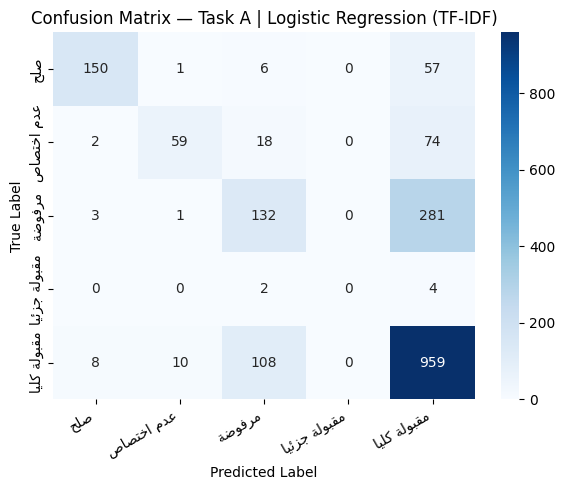

In [ ]:
# Task A: LR + TF-IDF unigram
print('Training Logistic Regression on Task A (TF-IDF unigram)')

lr_a = LogisticRegression(max_iter=1000, C=1.0, random_state=42, solver='saga', n_jobs=-1)
lr_a.fit(X_a_tfidf_train, y_a_train)
y_a_pred_lr = lr_a.predict(X_a_tfidf_test)

res = evaluate_model(y_a_test, y_a_pred_lr, le_a, 'Task A', 'Logistic Regression (TF-IDF)')
all_results.append(res)

Training Logistic Regression on Task B (TF-IDF unigram)

Task B | Logistic Regression (TF-IDF)


Metric,Score
Accuracy,0.697200
Precision (macro),0.678400
Recall (macro),0.601200
F1 (macro),0.627700
F1 (weighted),0.678100


,precision,recall,f1-score,support
شراكات تجارية,0.737700,0.569600,0.642900,79.000000
عقود بيع وتوريد,0.731200,0.862300,0.791400,1445.000000
نزاعات تجارية عامة,0.566200,0.371800,0.448800,702.000000
accuracy,0.697200,0.697200,0.697200,0.697200
macro avg,0.678400,0.601200,0.627700,2226.000000
weighted avg,0.679400,0.697200,0.678100,2226.000000


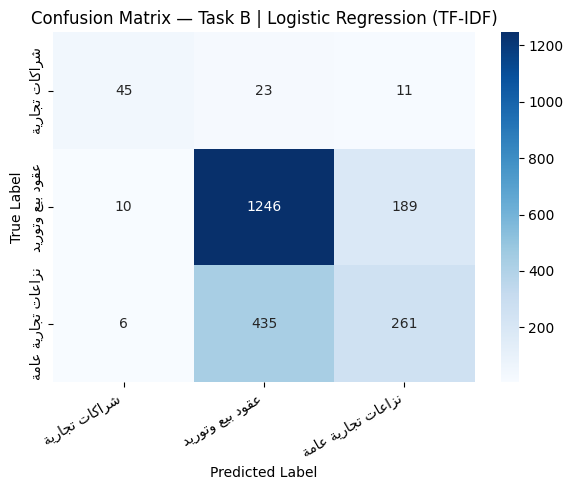

In [ ]:
# Task B: LR + TF-IDF unigram
print('Training Logistic Regression on Task B (TF-IDF unigram)')

lr_b = LogisticRegression(max_iter=1000, C=1.0, random_state=42, solver='saga', n_jobs=-1)
lr_b.fit(X_b_tfidf_train, y_b_train)
y_b_pred_lr = lr_b.predict(X_b_tfidf_test)

res = evaluate_model(y_b_test, y_b_pred_lr, le_b, 'Task B', 'Logistic Regression (TF-IDF)')
all_results.append(res)

## Section 10 — Model 2: Linear SVM

Training LinearSVC on Task A (TF-IDF bigram)

Task A | LinearSVC (TF-IDF bigram)


Metric,Score
Accuracy,0.722700
Precision (macro),0.591000
Recall (macro),0.521100
F1 (macro),0.549300
F1 (weighted),0.713800


,precision,recall,f1-score,support
صلح,0.950500,0.808400,0.873700,214.000000
عدم اختصاص,0.745300,0.516300,0.610000,153.000000
مرفوضة,0.512900,0.429300,0.467400,417.000000
مقبولة جزئياً,0.000000,0.000000,0.000000,6.000000
مقبولة كلياً,0.746400,0.851600,0.795500,1085.000000
accuracy,0.722700,0.722700,0.722700,0.722700
macro avg,0.591000,0.521100,0.549300,1875.000000
weighted avg,0.715300,0.722700,0.713800,1875.000000


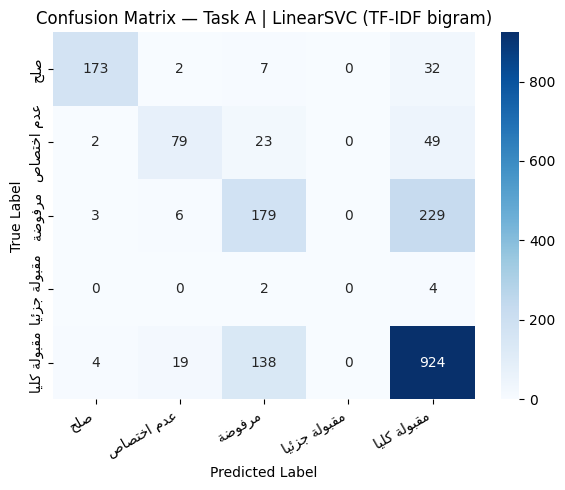

In [ ]:
# Task A: SVM + TF-IDF bigram
print('Training LinearSVC on Task A (TF-IDF bigram)')

svm_a = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm_a.fit(X_a_tfidf_bi_train, y_a_train)
y_a_pred_svm = svm_a.predict(X_a_tfidf_bi_test)

res = evaluate_model(y_a_test, y_a_pred_svm, le_a, 'Task A', 'LinearSVC (TF-IDF bigram)')
all_results.append(res)

Training LinearSVC on Task B (TF-IDF bigram)

Task B | LinearSVC (TF-IDF bigram)


Metric,Score
Accuracy,0.693200
Precision (macro),0.715500
Recall (macro),0.632000
F1 (macro),0.666100
F1 (weighted),0.687400


,precision,recall,f1-score,support
شراكات تجارية,0.859600,0.620300,0.720600,79.000000
عقود بيع وتوريد,0.747600,0.805500,0.775500,1445.000000
نزاعات تجارية عامة,0.539200,0.470100,0.502300,702.000000
accuracy,0.693200,0.693200,0.693200,0.693200
macro avg,0.715500,0.632000,0.666100,2226.000000
weighted avg,0.685900,0.693200,0.687400,2226.000000


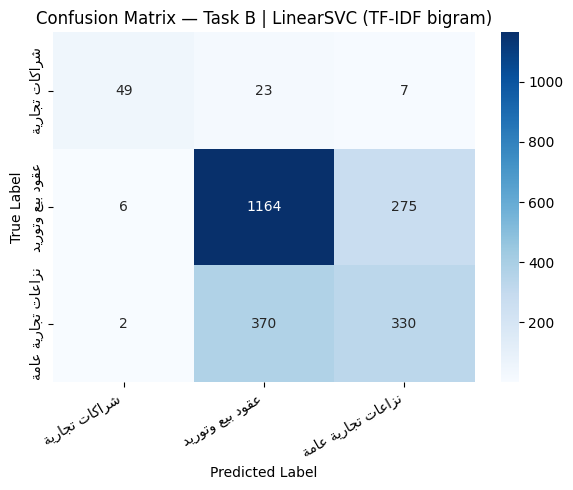

In [ ]:
# Task B: SVM + TF-IDF bigram
print('Training LinearSVC on Task B (TF-IDF bigram)')

svm_b = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm_b.fit(X_b_tfidf_bi_train, y_b_train)
y_b_pred_svm = svm_b.predict(X_b_tfidf_bi_test)

res = evaluate_model(y_b_test, y_b_pred_svm, le_b, 'Task B', 'LinearSVC (TF-IDF bigram)')
all_results.append(res)

## Section 11 — Hyperparameter Tuning (GridSearch on SVM)

Running GridSearch for SVM on Task A
Fitting 3 folds for each of 6 candidates, totalling 18 fits

Best params (Task A): {'clf__C': 1.0, 'tfidf__ngram_range': (1, 2)}
Best CV F1 (weighted): 0.6949

Task A | SVM GridSearch (best)


Metric,Score
Accuracy,0.722700
Precision (macro),0.591000
Recall (macro),0.521100
F1 (macro),0.549300
F1 (weighted),0.713800


,precision,recall,f1-score,support
صلح,0.950500,0.808400,0.873700,214.000000
عدم اختصاص,0.745300,0.516300,0.610000,153.000000
مرفوضة,0.512900,0.429300,0.467400,417.000000
مقبولة جزئياً,0.000000,0.000000,0.000000,6.000000
مقبولة كلياً,0.746400,0.851600,0.795500,1085.000000
accuracy,0.722700,0.722700,0.722700,0.722700
macro avg,0.591000,0.521100,0.549300,1875.000000
weighted avg,0.715300,0.722700,0.713800,1875.000000


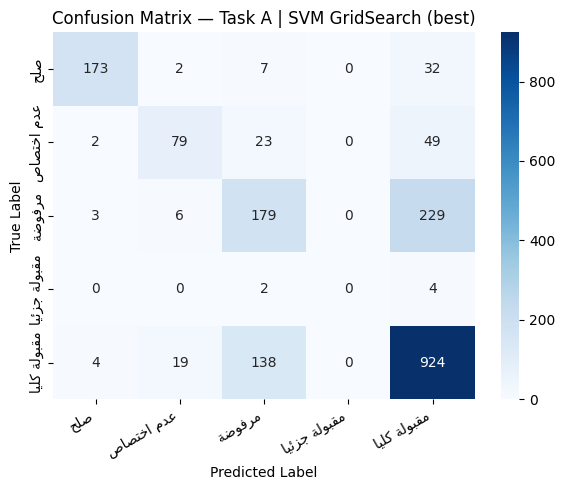

In [ ]:
# Grid search on Task A — SVM with TF-IDF
# Using a small grid to keep runtime short
print('Running GridSearch for SVM on Task A')

pipe_a = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000)),
    ('clf',   LinearSVC(max_iter=2000, random_state=42))
])

param_grid_a = {
    'tfidf__ngram_range': [(1,1), (1,2)],
    'clf__C': [0.1, 1.0, 5.0]
}

cv_a = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid_a = GridSearchCV(pipe_a, param_grid_a, cv=cv_a, scoring='f1_weighted', n_jobs=-1, verbose=1)
grid_a.fit(X_a_train, y_a_train)

print(f'\nBest params (Task A): {grid_a.best_params_}')
print(f'Best CV F1 (weighted): {grid_a.best_score_:.4f}')

y_a_pred_grid = grid_a.predict(X_a_test)
res = evaluate_model(y_a_test, y_a_pred_grid, le_a, 'Task A', 'SVM GridSearch (best)')
all_results.append(res)

Running GridSearch for SVM on Task B
Fitting 3 folds for each of 6 candidates, totalling 18 fits

Best params (Task B): {'clf__C': 1.0, 'tfidf__ngram_range': (1, 2)}
Best CV F1 (weighted): 0.6945

Task B | SVM GridSearch (best)


Metric,Score
Accuracy,0.693200
Precision (macro),0.715500
Recall (macro),0.632000
F1 (macro),0.666100
F1 (weighted),0.687400


,precision,recall,f1-score,support
شراكات تجارية,0.859600,0.620300,0.720600,79.000000
عقود بيع وتوريد,0.747600,0.805500,0.775500,1445.000000
نزاعات تجارية عامة,0.539200,0.470100,0.502300,702.000000
accuracy,0.693200,0.693200,0.693200,0.693200
macro avg,0.715500,0.632000,0.666100,2226.000000
weighted avg,0.685900,0.693200,0.687400,2226.000000


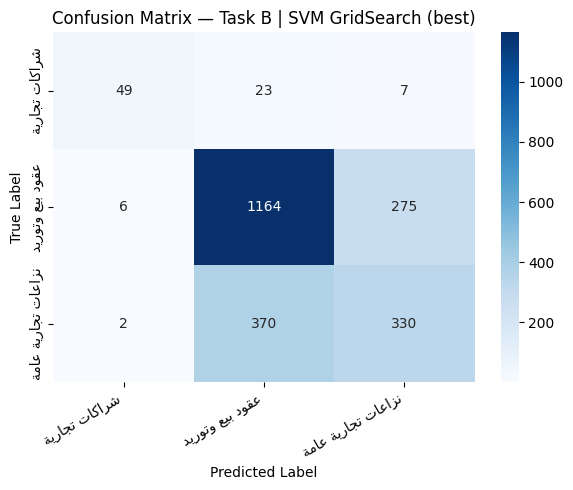

In [ ]:
# Grid search on Task B
print('Running GridSearch for SVM on Task B')

pipe_b = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000)),
    ('clf',   LinearSVC(max_iter=2000, random_state=42))
])

param_grid_b = {
    'tfidf__ngram_range': [(1,1), (1,2)],
    'clf__C': [0.1, 1.0, 5.0]
}

cv_b = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid_b = GridSearchCV(pipe_b, param_grid_b, cv=cv_b, scoring='f1_weighted', n_jobs=-1, verbose=1)
grid_b.fit(X_b_train, y_b_train)

print(f'\nBest params (Task B): {grid_b.best_params_}')
print(f'Best CV F1 (weighted): {grid_b.best_score_:.4f}')

y_b_pred_grid = grid_b.predict(X_b_test)
res = evaluate_model(y_b_test, y_b_pred_grid, le_b, 'Task B', 'SVM GridSearch (best)')
all_results.append(res)

## Section 12 — Model 3: Feedforward Neural Network (ANN)

Input: TF-IDF features → Dense layers with Dropout → Softmax output

Training ANN on Task A


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     2,101,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,135,045 (8.14 MB)

 Trainable params: 2,135,045 (8.14 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.5868 - loss: 1.0797 - val_accuracy: 0.6440 - val_loss: 0.8756
Epoch 2/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7057 - loss: 0.7066 - val_accuracy: 0.6827 - val_loss: 0.7476
Epoch 3/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7949 - loss: 0.5141 - val_accuracy: 0.6587 - val_loss: 0.7697
Epoch 4/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8536 - loss: 0.3722 - val_accuracy: 0.6520 - val_loss: 0.8546
Epoch 5/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8917 - loss: 0.2824 - val_accuracy: 0.6453 - val_loss: 0.9490
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

Task A | ANN (TF-IDF)


Metric,Score
Accuracy,0.695500
Precision (macro),0.571200
Recall (macro),0.491500
F1 (macro),0.520800
F1 (weighted),0.685000


,precision,recall,f1-score,support
صلح,0.857100,0.757000,0.804000,214.000000
عدم اختصاص,0.788900,0.464100,0.584400,153.000000
مرفوضة,0.488400,0.405300,0.443000,417.000000
مقبولة جزئياً,0.000000,0.000000,0.000000,6.000000
مقبولة كلياً,0.721600,0.831300,0.772600,1085.000000
accuracy,0.695500,0.695500,0.695500,0.695500
macro avg,0.571200,0.491500,0.520800,1875.000000
weighted avg,0.688400,0.695500,0.685000,1875.000000


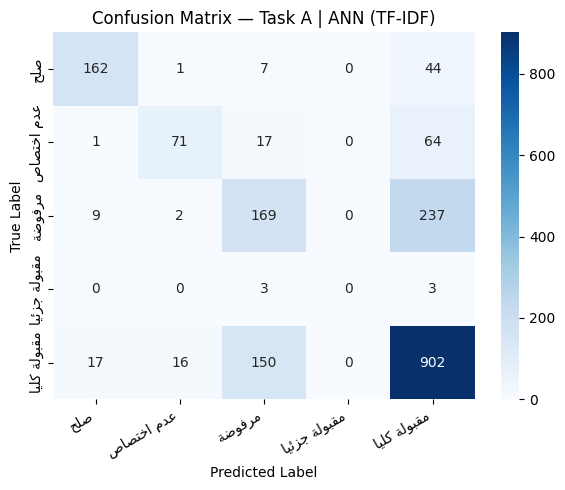

In [ ]:
def build_ann(input_dim, num_classes):
    model = Sequential([
        Dense(256, activation='relu', input_shape=(input_dim,)),
        Dropout(0.4),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# Task A ANN
print('Training ANN on Task A')

n_classes_a = len(le_a.classes_)
ann_a = build_ann(X_a_tfidf_train.shape[1], n_classes_a)
ann_a.summary()

es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_a = ann_a.fit(
    X_a_tfidf_train.toarray(), y_a_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    callbacks=[es],
    verbose=1
)

y_a_pred_ann = np.argmax(ann_a.predict(X_a_tfidf_test.toarray()), axis=1)
res = evaluate_model(y_a_test, y_a_pred_ann, le_a, 'Task A', 'ANN (TF-IDF)')
all_results.append(res)

Training ANN on Task B
Epoch 1/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.6483 - loss: 0.7254 - val_accuracy: 0.6461 - val_loss: 0.6389
Epoch 2/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7330 - loss: 0.5557 - val_accuracy: 0.6629 - val_loss: 0.6405
Epoch 3/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8111 - loss: 0.4390 - val_accuracy: 0.6640 - val_loss: 0.7314
Epoch 4/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8516 - loss: 0.3459 - val_accuracy: 0.6562 - val_loss: 0.8273
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

Task B | ANN (TF-IDF)


Metric,Score
Accuracy,0.665800
Precision (macro),0.434600
Recall (macro),0.360700
F1 (macro),0.326200
F1 (weighted),0.572800


,precision,recall,f1-score,support
شراكات تجارية,0.000000,0.000000,0.000000,79.000000
عقود بيع وتوريد,0.667500,0.972300,0.791500,1445.000000
نزاعات تجارية عامة,0.636400,0.109700,0.187100,702.000000
accuracy,0.665800,0.665800,0.665800,0.665800
macro avg,0.434600,0.360700,0.326200,2226.000000
weighted avg,0.634000,0.665800,0.572800,2226.000000


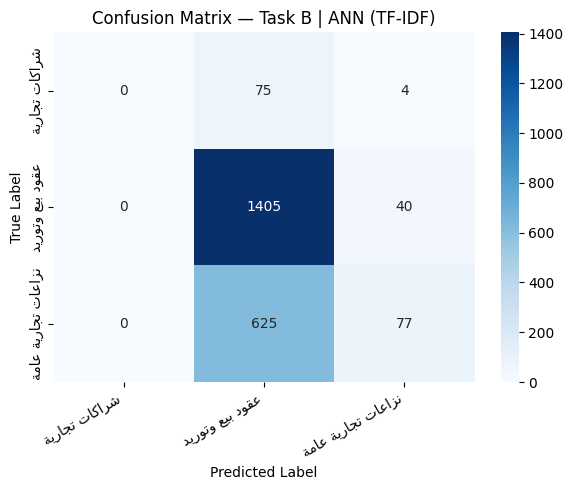

In [ ]:
# Task B ANN
print('Training ANN on Task B')

n_classes_b = len(le_b.classes_)
ann_b = build_ann(X_b_tfidf_train.shape[1], n_classes_b)

history_b = ann_b.fit(
    X_b_tfidf_train.toarray(), y_b_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    callbacks=[es],
    verbose=1
)

y_b_pred_ann = np.argmax(ann_b.predict(X_b_tfidf_test.toarray()), axis=1)
res = evaluate_model(y_b_test, y_b_pred_ann, le_b, 'Task B', 'ANN (TF-IDF)')
all_results.append(res)

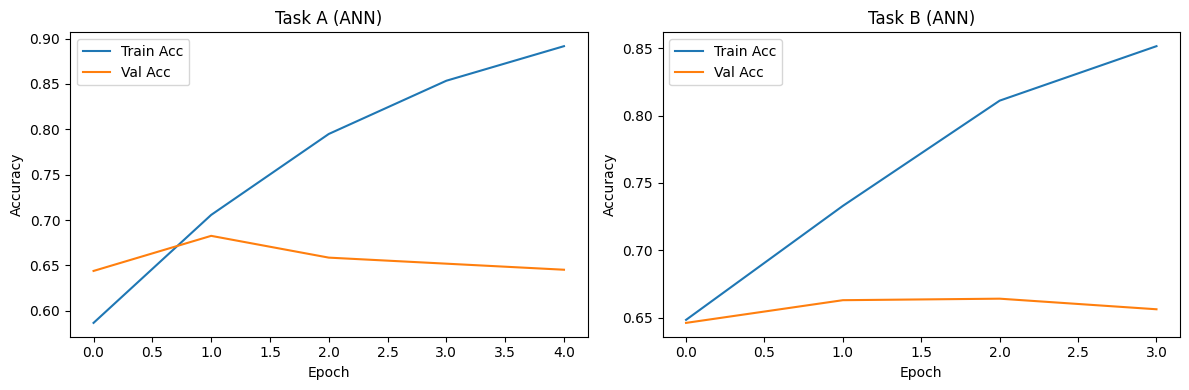

In [ ]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, hist, title in zip(axes, [history_a, history_b], ['Task A (ANN)', 'Task B (ANN)']):
    ax.plot(hist.history['accuracy'],     label='Train Acc')
    ax.plot(hist.history['val_accuracy'], label='Val Acc')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()

plt.tight_layout()
plt.show()

## Section 13 — Experiment Scenarios

We run **5 structured experiments** comparing preprocessing, features, and models.

Experiment 1: BoW vs TF-IDF (Task A, Logistic Regression)
BoW  → F1 weighted: 0.6649
TF-IDF → F1 weighted: 0.6709


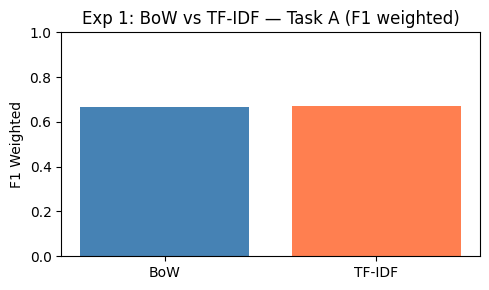

In [ ]:
# Experiment 1: BoW vs TF-IDF (Task A, LR)
print('Experiment 1: BoW vs TF-IDF (Task A, Logistic Regression)')

lr_bow = LogisticRegression(max_iter=1000, C=1.0, random_state=42, solver='saga', n_jobs=-1)
lr_bow.fit(X_a_bow_train, y_a_train)
y_bow = lr_bow.predict(X_a_bow_test)

bow_f1  = f1_score(y_a_test, y_bow, average='weighted', zero_division=0)
tfidf_f1 = f1_score(y_a_test, y_a_pred_lr, average='weighted', zero_division=0)

print(f'BoW  → F1 weighted: {bow_f1:.4f}')
print(f'TF-IDF → F1 weighted: {tfidf_f1:.4f}')

# Bar chart
plt.figure(figsize=(5, 3))
plt.bar(['BoW', 'TF-IDF'], [bow_f1, tfidf_f1], color=['steelblue', 'coral'])
plt.ylim(0, 1)
plt.title('Exp 1: BoW vs TF-IDF — Task A (F1 weighted)')
plt.ylabel('F1 Weighted')
plt.tight_layout()
plt.show()

all_results.append({'task': 'Task A', 'model': 'LR + BoW (Exp1)',
                    'accuracy': accuracy_score(y_a_test, y_bow),
                    'f1_weighted': bow_f1, 'f1_macro': f1_score(y_a_test, y_bow, average='macro', zero_division=0),
                    'precision_macro': 0, 'recall_macro': 0})

Experiment 2: With Stemming vs Without Stemming (Task A)
Without stemming → F1 weighted: 0.6827
With stemming    → F1 weighted: 0.6884


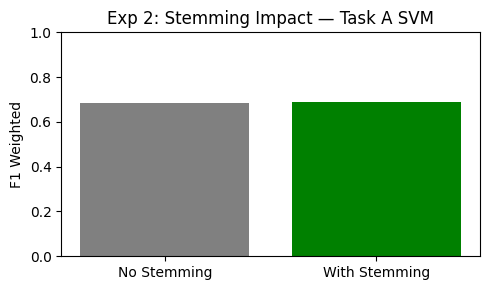

In [ ]:
# Experiment 2: Stemming vs No-Stemming (Task A, SVM)
print('Experiment 2: With Stemming vs Without Stemming (Task A)')

# No stemming
tfidf_nostem = TfidfVectorizer(max_features=10000)
X_a_nostem_train_feat = tfidf_nostem.fit_transform(X_a_train)  # X_a_train is stemmed

# Rebuild with no-stemmed text
X_ns_train, X_ns_test, y_ns_train, y_ns_test = train_test_split(
    df_a['clean_text_nostem'].values, y_a, test_size=0.2, random_state=42, stratify=y_a
)
tfidf_nostem2 = TfidfVectorizer(max_features=10000)
X_ns_train_feat = tfidf_nostem2.fit_transform(X_ns_train)
X_ns_test_feat  = tfidf_nostem2.transform(X_ns_test)

svm_ns = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm_ns.fit(X_ns_train_feat, y_ns_train)
y_ns_pred = svm_ns.predict(X_ns_test_feat)

# With stemming (already done)
svm_s = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm_s.fit(X_a_tfidf_train, y_a_train)
y_s_pred = svm_s.predict(X_a_tfidf_test)

f1_nostem = f1_score(y_ns_test, y_ns_pred, average='weighted', zero_division=0)
f1_stem   = f1_score(y_a_test, y_s_pred, average='weighted', zero_division=0)

print(f'Without stemming → F1 weighted: {f1_nostem:.4f}')
print(f'With stemming    → F1 weighted: {f1_stem:.4f}')

plt.figure(figsize=(5, 3))
plt.bar(['No Stemming', 'With Stemming'], [f1_nostem, f1_stem], color=['gray', 'green'])
plt.ylim(0, 1)
plt.title('Exp 2: Stemming Impact — Task A SVM')
plt.ylabel('F1 Weighted')
plt.tight_layout()
plt.show()

Experiment 3: Word N-grams vs Character N-grams (Task B)
Word N-grams → F1 weighted: 0.6754
Char N-grams → F1 weighted: 0.6725


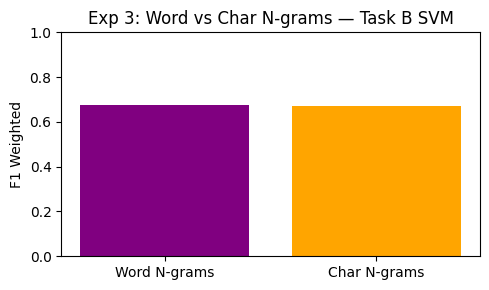

In [ ]:
# Experiment 3: Word N-grams vs Character N-grams (Task B, SVM)
print('Experiment 3: Word N-grams vs Character N-grams (Task B)')

svm_word = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm_word.fit(X_b_word_tri_train, y_b_train)
y_word = svm_word.predict(X_b_word_tri_test)

svm_char = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm_char.fit(X_b_char_tri_train, y_b_train)
y_char = svm_char.predict(X_b_char_tri_test)

f1_word = f1_score(y_b_test, y_word, average='weighted', zero_division=0)
f1_char = f1_score(y_b_test, y_char, average='weighted', zero_division=0)

print(f'Word N-grams → F1 weighted: {f1_word:.4f}')
print(f'Char N-grams → F1 weighted: {f1_char:.4f}')

plt.figure(figsize=(5, 3))
plt.bar(['Word N-grams', 'Char N-grams'], [f1_word, f1_char], color=['purple', 'orange'])
plt.ylim(0, 1)
plt.title('Exp 3: Word vs Char N-grams — Task B SVM')
plt.ylabel('F1 Weighted')
plt.tight_layout()
plt.show()

Experiment 4: Averaged Embeddings vs TF-IDF (Task A, LR)
AraVec Embeddings → F1 weighted: 0.6585
TF-IDF            → F1 weighted: 0.6709


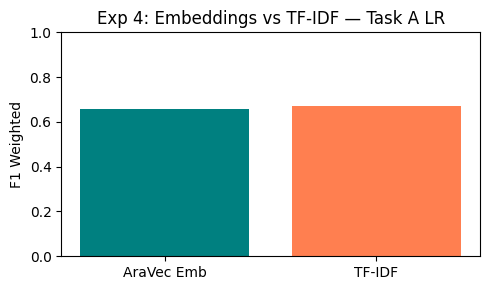

In [ ]:
# Experiment 4: Embeddings vs TF-IDF (Task A, LR)
print('Experiment 4: Averaged Embeddings vs TF-IDF (Task A, LR)')

lr_emb = LogisticRegression(max_iter=1000, C=1.0, random_state=42, solver='saga', n_jobs=-1)
lr_emb.fit(X_a_emb_train, y_a_train)
y_emb = lr_emb.predict(X_a_emb_test)

f1_emb   = f1_score(y_a_test, y_emb, average='weighted', zero_division=0)
f1_tfidf = f1_score(y_a_test, y_a_pred_lr, average='weighted', zero_division=0)

print(f'AraVec Embeddings → F1 weighted: {f1_emb:.4f}')
print(f'TF-IDF            → F1 weighted: {f1_tfidf:.4f}')

plt.figure(figsize=(5, 3))
plt.bar(['AraVec Emb', 'TF-IDF'], [f1_emb, f1_tfidf], color=['teal', 'coral'])
plt.ylim(0, 1)
plt.title('Exp 4: Embeddings vs TF-IDF — Task A LR')
plt.ylabel('F1 Weighted')
plt.tight_layout()
plt.show()

all_results.append({'task': 'Task A', 'model': 'LR + AraVec (Exp4)',
                    'accuracy': accuracy_score(y_a_test, y_emb),
                    'f1_weighted': f1_emb, 'f1_macro': f1_score(y_a_test, y_emb, average='macro', zero_division=0),
                    'precision_macro': 0, 'recall_macro': 0})

Experiment 5: Traditional ML vs ANN (Task A)


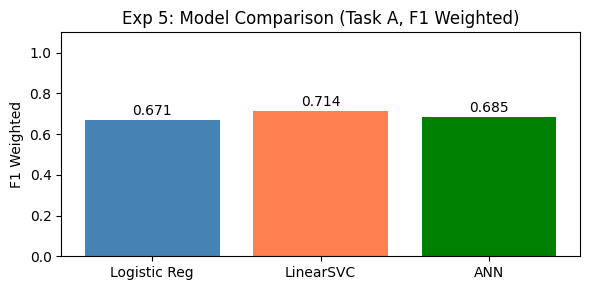

LR:  0.6709  |  SVM: 0.7138  |  ANN: 0.6850


In [ ]:
# Experiment 5: Traditional ML vs ANN (Task A)
print('Experiment 5: Traditional ML vs ANN (Task A)')

f1_lr  = f1_score(y_a_test, y_a_pred_lr,  average='weighted', zero_division=0)
f1_svm = f1_score(y_a_test, y_a_pred_svm, average='weighted', zero_division=0)
f1_ann = f1_score(y_a_test, y_a_pred_ann, average='weighted', zero_division=0)

models = ['Logistic Reg', 'LinearSVC', 'ANN']
scores = [f1_lr, f1_svm, f1_ann]

plt.figure(figsize=(6, 3))
bars = plt.bar(models, scores, color=['steelblue', 'coral', 'green'])
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.3f}', ha='center', va='bottom', fontsize=10)
plt.ylim(0, 1.1)
plt.title('Exp 5: Model Comparison (Task A, F1 Weighted)')
plt.ylabel('F1 Weighted')
plt.tight_layout()
plt.show()

print(f'LR:  {f1_lr:.4f}  |  SVM: {f1_svm:.4f}  |  ANN: {f1_ann:.4f}')

## Section 14 — Summary Results Table

In [ ]:
results_df = pd.DataFrame(all_results)
results_df = results_df[['task', 'model', 'accuracy', 'precision_macro',
                          'recall_macro', 'f1_macro', 'f1_weighted']]
results_df = results_df.round(4)

print(' All Results Summary')
styled = (results_df.style
    .background_gradient(subset=['accuracy', 'f1_macro', 'f1_weighted'], cmap='Blues')
    .highlight_max(subset=['accuracy', 'f1_macro', 'f1_weighted'], color='lightgreen')
    .set_caption('Model Performance Summary')
    .format({'accuracy': '{:.4f}', 'precision_macro': '{:.4f}',
             'recall_macro': '{:.4f}', 'f1_macro': '{:.4f}',
             'f1_weighted': '{:.4f}'})
)

display(styled)


 All Results Summary


,task,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,Task A,Logistic Regression (TF-IDF),0.6933,0.5890,0.4574,0.4977,0.6709
1,Task B,Logistic Regression (TF-IDF),0.6972,0.6784,0.6012,0.6277,0.6781
2,Task A,LinearSVC (TF-IDF bigram),0.7227,0.5910,0.5211,0.5493,0.7138
3,Task B,LinearSVC (TF-IDF bigram),0.6932,0.7155,0.6320,0.6661,0.6874
4,Task A,SVM GridSearch (best),0.7227,0.5910,0.5211,0.5493,0.7138
5,Task B,SVM GridSearch (best),0.6932,0.7155,0.6320,0.6661,0.6874
6,Task A,ANN (TF-IDF),0.6955,0.5712,0.4915,0.5208,0.6850
7,Task B,ANN (TF-IDF),0.6658,0.4346,0.3607,0.3262,0.5728
8,Task A,LR + BoW (Exp1),0.6693,0.0000,0.0000,0.5082,0.6649
9,Task A,LR + AraVec (Exp4),0.6811,0.0000,0.0000,0.4890,0.6585


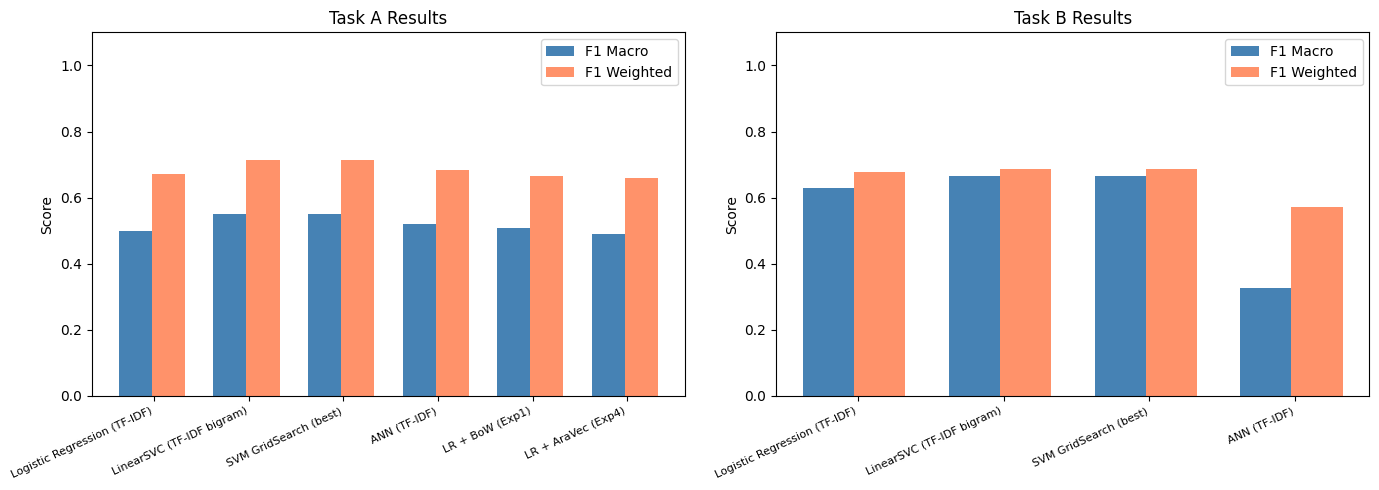

In [ ]:
# Visual summary — grouped bar chart
task_a_res = results_df[results_df['task'] == 'Task A'].copy()
task_b_res = results_df[results_df['task'] == 'Task B'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, tdf, title in zip(axes, [task_a_res, task_b_res], ['Task A Results', 'Task B Results']):
    x = range(len(tdf))
    ax.bar([i - 0.2 for i in x], tdf['f1_macro'],    width=0.35, label='F1 Macro',    color='steelblue')
    ax.bar([i + 0.15 for i in x], tdf['f1_weighted'], width=0.35, label='F1 Weighted', color='coral', alpha=0.85)
    ax.set_xticks(list(x))
    ax.set_xticklabels(tdf['model'], rotation=25, ha='right', fontsize=8)
    ax.set_ylim(0, 1.1)
    ax.set_title(title)
    ax.set_ylabel('Score')
    ax.legend()

plt.tight_layout()
plt.show()

## Section 15 — Error Analysis

In [ ]:
# Task A: Error Analysis on best model (SVM GridSearch)
print('Task A: Error Analysis')

# Proper index tracking
df_a_reset = df_a.reset_index(drop=True)
_, test_idx_a = train_test_split(
    df_a_reset.index, test_size=0.2, random_state=42,
    stratify=y_a
)

test_df_a = df_a_reset.loc[test_idx_a].copy().reset_index(drop=True)
test_df_a['true_label'] = le_a.inverse_transform(y_a_test)
test_df_a['predicted'] = le_a.inverse_transform(y_a_pred_grid)

misclassified_a = test_df_a[test_df_a['predicted'] != test_df_a['true_label']]

print(f'Total misclassified (Task A): {len(misclassified_a)} / {len(test_df_a)}')
print(f'Error rate: {len(misclassified_a)/len(test_df_a):.2%}')

# Error pairs table
error_pairs_a = (misclassified_a
    .groupby(['true_label', 'predicted'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False))

display(error_pairs_a.style
    .background_gradient(subset=['count'], cmap='Reds')
    .set_caption('Task A — Most Common Misclassification Pairs')
)

Task A: Error Analysis
Total misclassified (Task A): 520 / 1875
Error rate: 27.73%


,true_label,predicted,count
8,مرفوضة,مقبولة كلياً,229
13,مقبولة كلياً,مرفوضة,138
5,عدم اختصاص,مقبولة كلياً,49
2,صلح,مقبولة كلياً,32
4,عدم اختصاص,مرفوضة,23
12,مقبولة كلياً,عدم اختصاص,19
1,صلح,مرفوضة,7
7,مرفوضة,عدم اختصاص,6
11,مقبولة كلياً,صلح,4
10,مقبولة جزئياً,مقبولة كلياً,4


In [ ]:
# Sample misclassified cases - Task A
sample_a = misclassified_a.head(3)[['true_label', 'predicted', 'case_facts_text']].copy()
sample_a['case_facts_text'] = sample_a['case_facts_text'].apply(lambda x: str(x)[:200])
sample_a.columns = ['True Label', 'Predicted', 'Case Facts (first 200 chars)']
sample_a = sample_a.reset_index(drop=True)

display(sample_a.style
    .set_caption('Sample Misclassified Cases — Task A')
    .set_properties(**{
        'text-align': 'right',
        'direction': 'rtl',
        'white-space': 'pre-wrap',
        'max-width': '400px'
    })
    .set_properties(subset=['True Label', 'Predicted'], **{
        'font-weight': 'bold'
    })
)

,True Label,Predicted,Case Facts (first 200 chars)
0,صلح,مقبولة كلياً,"['1. في 6/5/1441هـ الموافق 1/1/2020م، تم الاتفاق بين المدعية والمدعى عليها على توريد المدعي للمدعى عليها حشوات كنافة بثمن إجمالي قدره 28,937.28 ريال سعودي.' '2. استلمت المدعى عليها كامل المبيع ولم يس"
1,مقبولة كلياً,مرفوضة,"['1- تقدم وكيل المدعي بصحيفة دعوى ضد المدعى عليه يطلب فيها فسخ عقد شركة مضاربة شفوي غير محدد العقار وطلب إلزام المدعى عليه برد رأس المال البالغ 12,800 ريال لعدم قيام المدعى عليه بالعمل المتفق عليه (شر"
2,عدم اختصاص,مقبولة كلياً,"['1- وكيل المدعي قدم لائحة دعوى إلى المحكمة التجارية بجدة يوضح فيها اتفاق موكله مع المدعى عليها على شراكة.' '2- قام المدعي بتسليم المدعى عليها مبلغ (100,000) ريال كجزء من رأس المال لاستثماره في مشروع"


In [ ]:
# Task B: Error Analysis
print('\nTask B: Error Analysis')

df_b_reset = df_b.reset_index(drop=True)
_, test_idx_b = train_test_split(
    df_b_reset.index, test_size=0.2, random_state=42,
    stratify=y_b
)

test_df_b = df_b_reset.loc[test_idx_b].copy().reset_index(drop=True)
test_df_b['true_label'] = le_b.inverse_transform(y_b_test)
test_df_b['predicted'] = le_b.inverse_transform(y_b_pred_grid)

misclassified_b = test_df_b[test_df_b['predicted'] != test_df_b['true_label']]

print(f'Total misclassified (Task B): {len(misclassified_b)} / {len(test_df_b)}')
print(f'Error rate: {len(misclassified_b)/len(test_df_b):.2%}')

error_pairs_b = (misclassified_b
    .groupby(['true_label', 'predicted'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False))

display(error_pairs_b.style
    .background_gradient(subset=['count'], cmap='Reds')
    .set_caption('Task B — Most Common Misclassification Pairs')
)

# Sample misclassified cases - Task B
sample_b = misclassified_b.head(3)[['true_label', 'predicted', 'case_facts_text']].copy()
sample_b['case_facts_text'] = sample_b['case_facts_text'].apply(lambda x: str(x)[:200])
sample_b.columns = ['True Label', 'Predicted', 'Case Facts (first 200 chars)']
sample_b = sample_b.reset_index(drop=True)

display(sample_b.style
    .set_caption('Sample Misclassified Cases — Task B')
    .set_properties(**{
        'text-align': 'right',
        'direction': 'rtl',
        'white-space': 'pre-wrap',
        'max-width': '400px'
    })
    .set_properties(subset=['True Label', 'Predicted'], **{
        'font-weight': 'bold'
    })
)



Task B: Error Analysis
Total misclassified (Task B): 683 / 2226
Error rate: 30.68%


,true_label,predicted,count
5,نزاعات تجارية عامة,عقود بيع وتوريد,370
3,عقود بيع وتوريد,نزاعات تجارية عامة,275
0,شراكات تجارية,عقود بيع وتوريد,23
1,شراكات تجارية,نزاعات تجارية عامة,7
2,عقود بيع وتوريد,شراكات تجارية,6
4,نزاعات تجارية عامة,شراكات تجارية,2


,True Label,Predicted,Case Facts (first 200 chars)
0,نزاعات تجارية عامة,عقود بيع وتوريد,"['1- في تاريخ 1437/07/24هـ، أبرمت المدعية والمدعى عليها اتفاقاً يقضي بأن تبيع المدعية للمدعى عليها إطارات وبطاريات بقيمة إجمالية قدرها 6,979 ريالاً.' '2- تم الاتفاق على تسليم المبلغ على دفعة واحدة بت"
1,عقود بيع وتوريد,نزاعات تجارية عامة,"['1- تقدم وكيل المدعية بلائحة دعوى إلى المحكمة التجارية بالدمام يوضح فيها أن المدعية أبرمت اتفاقية بتاريخ 14/6/1443هـ مع المدعى عليها لتأجير معدات إنشائية لمدة سنة ميلادية بقيمة 555,757.82 ريال.' '2-"
2,عقود بيع وتوريد,نزاعات تجارية عامة,['1- تقدمت المدعية أصالة بدعوى عن طريق وكيلها مصعب خالد بن فهد أبالحسن بموجب وكالة رسمية، ويمثل المدعى عليها سالم بن مساعد بن سالم العجمي بموجب وكالة رسمية.' '2- أفاد وكيل المدعية أن الطرفين اتفقا بت


## Section 16 — [OPTIONAL] AraLegal-BERT Fine-tuning



config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/381 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Fine-tuning AraBERT on Task A...


Epoch,Training Loss,Validation Loss
1,0.846156,0.787463
2,0.786105,0.701978
3,0.551673,0.587993



Task A | AraBERT Fine-tuned [BONUS]


Metric,Score
Accuracy,0.750000
Precision (macro),0.625500
Recall (macro),0.549400
F1 (macro),0.574200
F1 (weighted),0.729400


,precision,recall,f1-score,support
صلح,0.979200,0.959200,0.969100,49.000000
عدم اختصاص,0.833300,0.555600,0.666700,45.000000
مرفوضة,0.571400,0.333300,0.421100,108.000000
مقبولة جزئياً,0.000000,0.000000,0.000000,1.000000
مقبولة كلياً,0.743700,0.899000,0.814000,297.000000
accuracy,0.750000,0.750000,0.750000,0.750000
macro avg,0.625500,0.549400,0.574200,500.000000
weighted avg,0.736200,0.750000,0.729400,500.000000


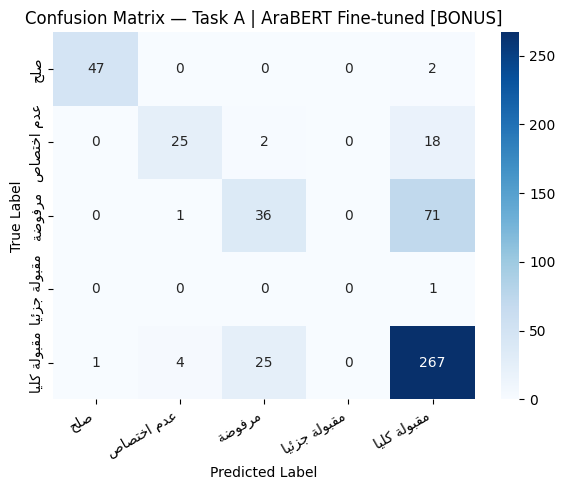

AraBERT fine-tuning complete.


In [ ]:
# [OPTIONAL — BONUS] Fine-tune AraBERT on Task A

RUN_BERT = True  # Set to True to run this section

if RUN_BERT:
    !pip install transformers -q
    from transformers import (
        AutoTokenizer, AutoModelForSequenceClassification,
        TrainingArguments, Trainer
    )
    import torch
    from torch.utils.data import Dataset

    MODEL_NAME = 'aubmindlab/bert-base-arabertv02'

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    class ArabicLegalDataset(Dataset):
        def __init__(self, texts, labels, tokenizer, max_len=256):
            self.texts  = texts
            self.labels = labels
            self.tok    = tokenizer
            self.max_len = max_len

        def __len__(self):
            return len(self.texts)

        def __getitem__(self, idx):
            enc = self.tok(
                self.texts[idx],
                max_length=self.max_len,
                padding='max_length',
                truncation=True,
                return_tensors='pt'
            )
            return {
                'input_ids':      enc['input_ids'].squeeze(),
                'attention_mask': enc['attention_mask'].squeeze(),
                'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
            }

    # Use raw (non-stemmed) text for BERT — it handles morphology internally
    X_a_nostem_train_raw, X_a_nostem_test_raw, ya_train_b, ya_test_b = train_test_split(
        df_a['clean_text_nostem'].values, y_a, test_size=0.2, random_state=42, stratify=y_a
    )

    # Small subset for quick fine-tuning (adjust as needed)
    SUBSET = 2000
    train_ds = ArabicLegalDataset(X_a_nostem_train_raw[:SUBSET], ya_train_b[:SUBSET], tokenizer)
    test_ds  = ArabicLegalDataset(X_a_nostem_test_raw[:500],    ya_test_b[:500],    tokenizer)

    model_bert = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=n_classes_a
    )

    training_args = TrainingArguments(
        output_dir='./arabert_task_a',
        num_train_epochs=3,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        eval_strategy='epoch',
        save_strategy='no',
        logging_steps=50,
        load_best_model_at_end=False,
        report_to='none'
    )

    trainer = Trainer(
        model=model_bert,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=test_ds
    )

    print('Fine-tuning AraBERT on Task A...')
    trainer.train()

    # Evaluate
    preds_bert = trainer.predict(test_ds)
    y_bert_pred = np.argmax(preds_bert.predictions, axis=1)
    res = evaluate_model(ya_test_b[:500], y_bert_pred, le_a, 'Task A', 'AraBERT Fine-tuned [BONUS]')
    all_results.append(res)
    print('AraBERT fine-tuning complete.')
else:
    print('[OPTIONAL] BERT section skipped. Set RUN_BERT = True to enable.')

## Section 17 — [BONUS] Gradio Interactive Demo

> **Bonus:** An interactive demo using Gradio that accepts Arabic case facts and returns predicted class and confidence.

In [ ]:
# [BONUS] Gradio demo
RUN_DEMO = True  # Set to False to skip

if RUN_DEMO:
    !pip install gradio -q
    import gradio as gr
    from sklearn.calibration import CalibratedClassifierCV

    # Wrap best models with probability output
    # Calibrate LinearSVC for probabilities
    best_tfidf_a = grid_a.best_estimator_.named_steps['tfidf']
    best_clf_a   = grid_a.best_estimator_.named_steps['clf']

    cal_svm_a = CalibratedClassifierCV(best_clf_a, cv='prefit')
    cal_svm_a.fit(best_tfidf_a.transform(X_a_train), y_a_train)

    best_tfidf_b = grid_b.best_estimator_.named_steps['tfidf']
    best_clf_b   = grid_b.best_estimator_.named_steps['clf']

    cal_svm_b = CalibratedClassifierCV(best_clf_b, cv='prefit')
    cal_svm_b.fit(best_tfidf_b.transform(X_b_train), y_b_train)

    def predict_case(case_text):
        if not case_text.strip():
            return 'Please enter Arabic case facts.', 'Please enter Arabic case facts.'

        cleaned = preprocess(case_text)

        # Task A
        feat_a = best_tfidf_a.transform([cleaned])
        proba_a = cal_svm_a.predict_proba(feat_a)[0]
        pred_a  = le_a.inverse_transform([np.argmax(proba_a)])[0]
        conf_a  = np.max(proba_a)
        result_a = f'**Verdict:** {pred_a}\n**Confidence:** {conf_a:.1%}'

        # Task B
        feat_b = best_tfidf_b.transform([cleaned])
        proba_b = cal_svm_b.predict_proba(feat_b)[0]
        pred_b  = le_b.inverse_transform([np.argmax(proba_b)])[0]
        conf_b  = np.max(proba_b)
        result_b = f'**Topic:** {pred_b}\n**Confidence:** {conf_b:.1%}'

        return result_a, result_b

    demo = gr.Interface(
        fn=predict_case,
        inputs=gr.Textbox(
            lines=6,
            placeholder='أدخل وقائع القضية هنا...',
            label='Case Facts (وقائع القضية)'
        ),
        outputs=[
            gr.Markdown(label='Task A — Verdict Prediction'),
            gr.Markdown(label='Task B — Legal Topic')
        ],
        title='Arabic Legal Case Classifier — CS476',
        description='Enter Arabic case facts to predict the verdict outcome and legal topic domain.',
        examples=[
            ['اتفق أطراف الدعوى على أن تورد المدعية للمدعى عليها عمالة بثمن إجمالي قدره لاير واستلمت المدعى عليها كامل المبيع ولم يسدد من الثمن شيء'],
            ['طالبت المدعية بإلزام المدعى عليها بتعويضها عن الضرر بسبب فسخ عقد شراكة ردت المدعى عليها بأن المدعية هي من فسخت العقد']
        ]
    )

    demo.launch(share=True, debug=False)
else:
    print('[BONUS] Demo skipped. Set RUN_DEMO = True to enable.')

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a9d168da6f56cdf3ab.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Section 18 — All Outputs

In [ ]:
# Final results table
final_df = pd.DataFrame(all_results).round(4)

styled_final = (final_df[['task', 'model', 'accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'f1_weighted']].style
    .background_gradient(subset=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'f1_weighted'], cmap='Blues')
    .highlight_max(subset=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'f1_weighted'], color='lightgreen')
    .set_caption('Final Model Performance Summary')
    .format({'accuracy': '{:.4f}', 'precision_macro': '{:.4f}',
             'recall_macro': '{:.4f}', 'f1_macro': '{:.4f}',
             'f1_weighted': '{:.4f}'})
)

display(styled_final)

,task,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,Task A,Logistic Regression (TF-IDF),0.6933,0.5890,0.4574,0.4977,0.6709
1,Task B,Logistic Regression (TF-IDF),0.6972,0.6784,0.6012,0.6277,0.6781
2,Task A,LinearSVC (TF-IDF bigram),0.7227,0.5910,0.5211,0.5493,0.7138
3,Task B,LinearSVC (TF-IDF bigram),0.6932,0.7155,0.6320,0.6661,0.6874
4,Task A,SVM GridSearch (best),0.7227,0.5910,0.5211,0.5493,0.7138
5,Task B,SVM GridSearch (best),0.6932,0.7155,0.6320,0.6661,0.6874
6,Task A,ANN (TF-IDF),0.6955,0.5712,0.4915,0.5208,0.6850
7,Task B,ANN (TF-IDF),0.6658,0.4346,0.3607,0.3262,0.5728
8,Task A,LR + BoW (Exp1),0.6693,0.0000,0.0000,0.5082,0.6649
9,Task A,LR + AraVec (Exp4),0.6811,0.0000,0.0000,0.4890,0.6585
